# Predicting House Prices with Linear Regression

## Objective

The objective of this project is to build and evaluate a Linear Regression model that predicts house prices using features such as area, number of bedrooms, bathrooms, age, city, and other property characteristics.

## Tech Stack

- Python
- Pandas
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
## import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import mean_squared_error, r2_score

import os

os.makedirs("images", exist_ok=True)


In [2]:
df = pd.read_csv("enhanced_house_price_dataset.csv")

df.head()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676


In [3]:
# Dataset Information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2000, 16)

Column Names:
['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'City', 'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply', 'Air Conditioning', 'Preferred Tenant', 'Locality Rating', 'Price']

Data Types:
Area                 int64
Bedrooms             int64
Bathrooms            int64
Stories              int64
Parking              int64
Age                  int64
City                object
Furnishing          object
Main Road           object
Guest Room          object
Basement            object
Water Supply        object
Air Conditioning    object
Preferred Tenant    object
Locality Rating      int64
Price                int64
dtype: object


## EDA

In [4]:
print("Missing Values Per Column:")

df.isnull().sum()

Missing Values Per Column:


Area                0
Bedrooms            0
Bathrooms           0
Stories             0
Parking             0
Age                 0
City                0
Furnishing          0
Main Road           0
Guest Room          0
Basement            0
Water Supply        0
Air Conditioning    0
Preferred Tenant    0
Locality Rating     0
Price               0
dtype: int64

## Missing Value Analysis

The dataset was checked for missing values across all columns.

No missing values were found in the dataset. Therefore, no imputation was required.

However, missing value handling is an important preprocessing step and will be considered before model training.

In [5]:
df.describe()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,3238.081000,3.031000,2.02150,1.996000,0.990500,24.008500,5.357500,1.245014e+06
std,1604.510239,1.427255,0.81263,0.811981,0.806682,14.319076,2.843015,3.001744e+05
min,401.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,3.346350e+05
25%,1860.000000,2.000000,1.00000,1.000000,0.000000,12.000000,3.000000,1.035278e+06
50%,3271.500000,3.000000,2.00000,2.000000,1.000000,24.000000,5.000000,1.246602e+06
75%,4599.750000,4.000000,3.00000,3.000000,2.000000,36.000000,8.000000,1.453607e+06
max,5996.000000,5.000000,3.00000,3.000000,2.000000,49.000000,10.000000,2.225409e+06


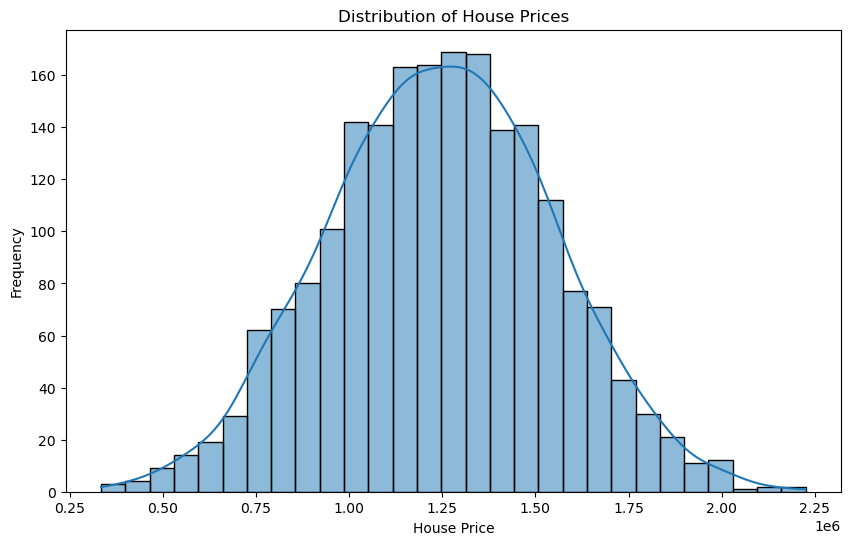

In [6]:
#Price Distribution
plt.figure(figsize=(10, 6))

sns.histplot(df["Price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.savefig(
    "images/price_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

## Observation: House Price Distribution

The distribution of house prices provides an overview of the range and frequency of property prices in the dataset.

The distribution helps identify whether house prices are normally distributed or contain skewness and extreme values.

# Feature Selection

The following features are expected to influence house prices:

- **Area:** Larger houses generally have higher prices.
- **Bedrooms:** More bedrooms can increase the value and usability of a property.
- **Bathrooms:** Additional bathrooms may increase property value.
- **Age:** Older properties may have lower prices depending on their condition.
- **City:** Property prices can vary significantly based on location.
- **Parking:** Parking availability can increase the value of a property.
- **Locality Rating:** A better locality rating may be associated with higher property prices.
- **Air Conditioning:** Houses with air conditioning may have higher market value.
- **Furnishing:** Fully furnished houses may be priced higher than unfurnished houses.

These features were selected because they represent property size, facilities, age, and location-related characteristics that are likely to influence house prices.

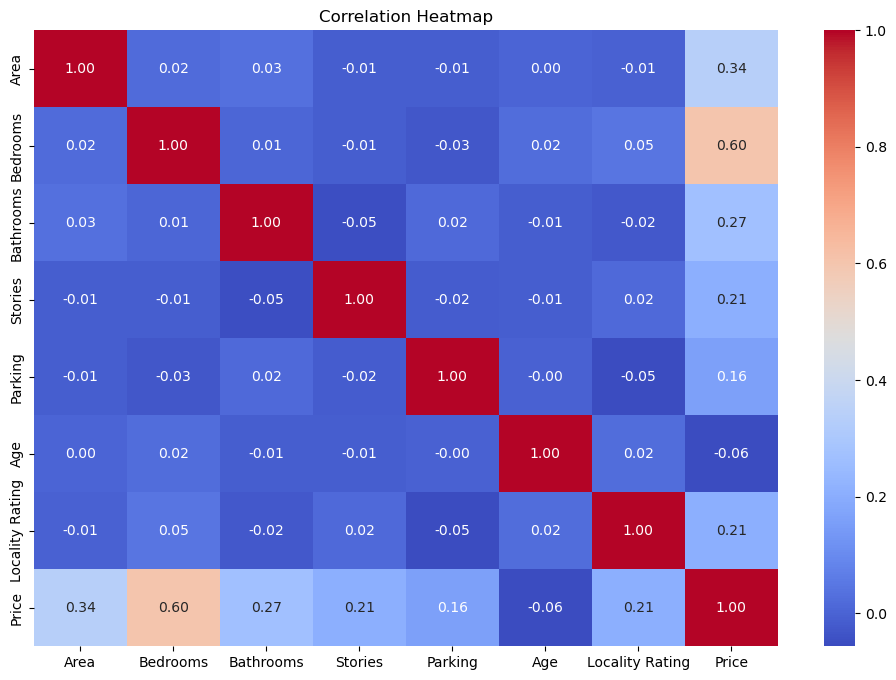

In [7]:
#CORRELATION HEATMAP
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "images/correlation_heatmap.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [8]:
# Price correlation 
price_correlation = numeric_df.corr()["Price"].sort_values(
    ascending=False
)
print(price_correlation)

Price              1.000000
Bedrooms           0.600588
Area               0.339137
Bathrooms          0.267506
Locality Rating    0.205792
Stories            0.205615
Parking            0.159216
Age               -0.056614
Name: Price, dtype: float64


## Correlation Analysis

The correlation analysis was performed to identify numerical features that have a strong relationship with house prices.

Features with higher positive correlation values are more likely to contribute positively to the predicted house price.

However, correlation alone does not prove causation, and categorical features will also be included in the model after encoding.

## DATA PREPROCESSING

In [9]:
# target and feature 
X = df.drop("Price", axis=1)
y = df["Price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2000, 15)
Target Shape: (2000,)


In [10]:
# handel missing values 
# Numerical columns
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

# Categorical columns
categorical_columns = X.select_dtypes(include=["object"]).columns

# Fill missing numerical values with median
X[numerical_columns] = X[numerical_columns].fillna(
    X[numerical_columns].median()
)

# Fill missing categorical values with mode
for column in categorical_columns:
    X[column] = X[column].fillna(
        X[column].mode()[0]
    )

print("Missing Values After Handling:")
print(X.isnull().sum().sum())

Missing Values After Handling:
0


## Missing Value Handling

The dataset was checked for missing values before model training.

Numerical missing values would be replaced using the median, while categorical missing values would be replaced using the mode.

In this dataset, no missing values were present, so no actual imputation was required.

In [11]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape After Encoding:", X_encoded.shape)

X_encoded.head()

Shape After Encoding: (2000, 23)


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,City_Chennai,City_Delhi,City_Hyderabad,...,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Main Road_Yes,Guest Room_Yes,Basement_Yes,Water Supply_Both,Water Supply_Corporation,Air Conditioning_Yes,Preferred Tenant_Company,Preferred Tenant_Family
0,1260,4,3,2,1,24,4,False,False,False,...,True,False,True,True,True,True,False,False,True,False
1,5790,2,1,1,1,7,5,False,False,False,...,False,True,True,True,True,True,False,True,False,False
2,5626,5,2,3,0,15,6,True,False,False,...,True,False,False,True,True,False,True,True,True,False
3,5591,1,1,1,1,47,3,False,True,False,...,False,False,True,False,True,False,False,False,True,False
4,4172,5,1,1,1,44,1,False,True,False,...,False,True,False,False,False,False,False,True,False,False


## Categorical Feature Encoding

Machine learning models require numerical input.

Therefore, categorical features were converted into numerical format using One-Hot Encoding.

One-Hot Encoding creates separate binary columns for each category and prevents the model from assuming an incorrect numerical order between categories.

## Train_test_split 

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 23)
Testing Data Shape: (400, 23)


## Train-Test Split

The dataset was divided into:

- 80% Training Data
- 20% Testing Data

The training dataset is used to train the Linear Regression model, while the testing dataset is used to evaluate its performance on unseen data.

In [13]:
## train linear regression model 
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [14]:
# make predication 
y_pred = model.predict(X_test)

print("First 10 Predictions:")

for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(
        "Actual:", round(actual, 2),
        "| Predicted:", round(predicted, 2)
    )

First 10 Predictions:
Actual: 936067 | Predicted: 986167.53
Actual: 1327841 | Predicted: 1380070.72
Actual: 1436138 | Predicted: 1377017.77
Actual: 1258537 | Predicted: 807907.19
Actual: 886765 | Predicted: 1000068.9
Actual: 1358758 | Predicted: 1129747.32
Actual: 1322617 | Predicted: 1390805.52
Actual: 1076983 | Predicted: 1265330.95
Actual: 778863 | Predicted: 767820.96
Actual: 1687160 | Predicted: 1661209.12


In [15]:
# model Evaluation 
mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Squared Error (MSE): 20133032720.03
Root Mean Squared Error (RMSE): 141890.92
R² Score: 0.7779


## Model Evaluation

The Linear Regression model was evaluated using:

- **Mean Squared Error (MSE):** Measures the average squared prediction error.
- **Root Mean Squared Error (RMSE):** Shows the typical prediction error in the same unit as house price.
- **R² Score:** Measures how much variation in house prices is explained by the model.

A lower MSE and RMSE indicate better prediction accuracy, while an R² score closer to 1 indicates a better model fit.

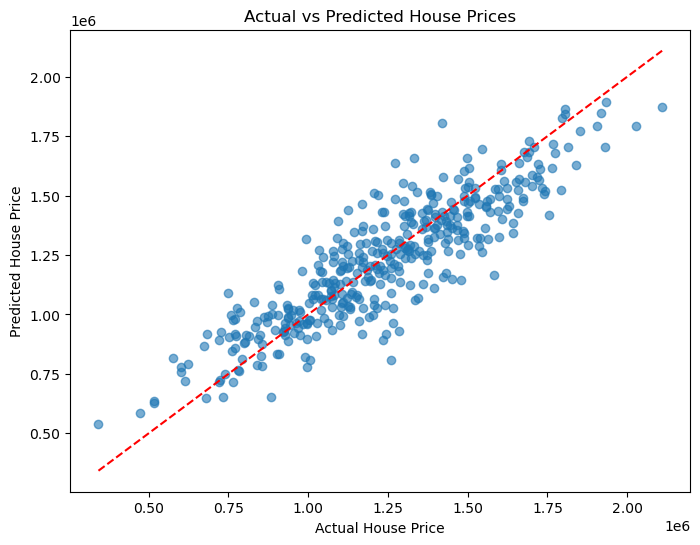

In [16]:
## actual VS predicated values 
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig(
    "images/actual_vs_predicted.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

## Actual vs Predicted Price Analysis

The scatter plot compares the actual house prices with the predicted prices.

The diagonal reference line represents perfect predictions.

Points closer to the diagonal line indicate that the model is making more accurate predictions.

## RESIDUAL PLOT

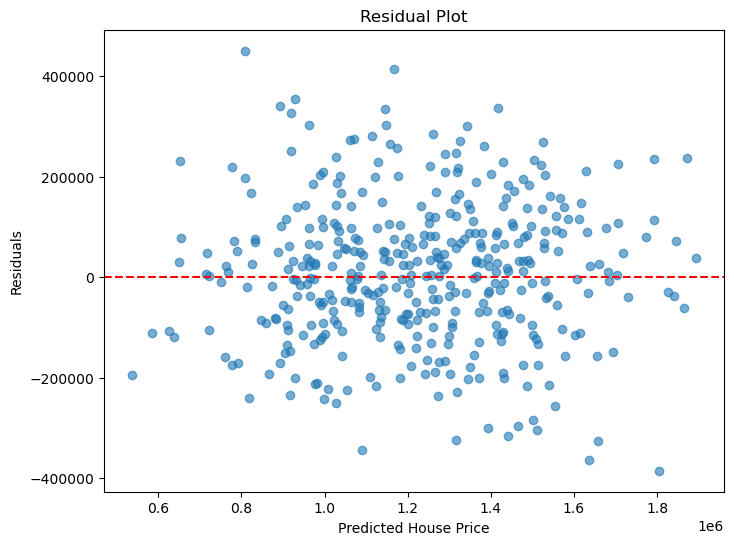

In [18]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.savefig(
    "images/residual_plot.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [19]:
coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
1,Bedrooms,124147.976086
2,Bathrooms,91184.406752
20,Air Conditioning_Yes,90281.538453
3,Stories,84013.158222
4,Parking,69110.976595
15,Main Road_Yes,55432.069158
17,Basement_Yes,53941.414709
16,Guest Room_Yes,53354.271357
6,Locality Rating,20277.055332
9,City_Hyderabad,9631.247998


In [20]:
#Top Positive and Negative Features
print("Top 10 Features with Highest Positive Impact:")

print(
    coefficients.head(10)
)

print("\nTop 10 Features with Highest Negative Impact:")

print(
    coefficients.tail(10)
)

Top 10 Features with Highest Positive Impact:
                 Feature    Coefficient
1               Bedrooms  124147.976086
2              Bathrooms   91184.406752
20  Air Conditioning_Yes   90281.538453
3                Stories   84013.158222
4                Parking   69110.976595
15         Main Road_Yes   55432.069158
17          Basement_Yes   53941.414709
16        Guest Room_Yes   53354.271357
6        Locality Rating   20277.055332
9         City_Hyderabad    9631.247998

Top 10 Features with Highest Negative Impact:
                      Feature    Coefficient
0                        Area      58.725517
5                         Age   -1694.672386
10               City_Kolkata   -2821.677261
21   Preferred Tenant_Company   -3447.515704
8                  City_Delhi   -4173.773328
19   Water Supply_Corporation   -4234.614001
12                  City_Pune  -12202.883518
18          Water Supply_Both  -19706.008138
13  Furnishing_Semi-Furnished  -80372.839984
14     Furnishing

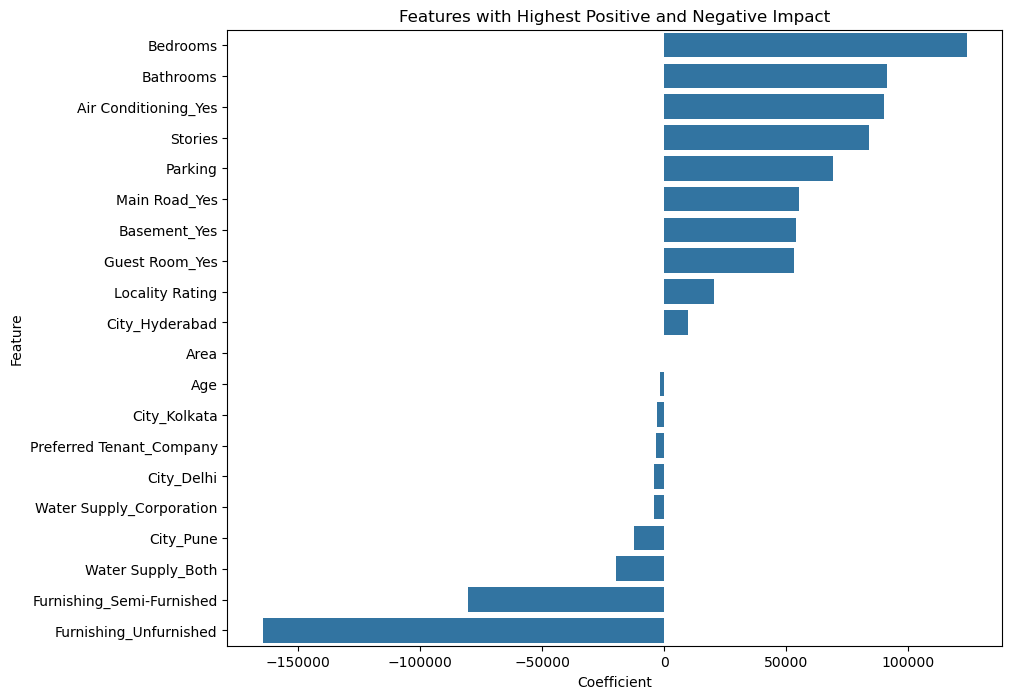

In [21]:
top_features = pd.concat([
    coefficients.head(10),
    coefficients.tail(10)
])

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Features with Highest Positive and Negative Impact"
)

plt.savefig(
    "images/coefficient_analysis.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

## Coefficient Analysis

Linear Regression coefficients indicate how each feature affects the predicted house price while keeping other features constant.

- A positive coefficient indicates that an increase in the feature is associated with an increase in house price.
- A negative coefficient indicates that an increase in the feature is associated with a decrease in house price.

The magnitude of a coefficient indicates the strength of its influence, although coefficients should be interpreted carefully when features have different scales.

## RIDGE REGRESSION COMPARISON

In [23]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train,
    y_train
)

ridge_pred = ridge_model.predict(
    X_test
)

In [24]:
ridge_mse = mean_squared_error(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(
    ridge_mse
)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    
    "MSE": [
        mse,
        ridge_mse
    ],
    
    "RMSE": [
        rmse,
        ridge_rmse
    ],
    
    "R² Score": [
        r2,
        ridge_r2
    ]
})

comparison

,Model,MSE,RMSE,R² Score
0,Linear Regression,2.013303e+10,141890.918385,0.777884
1,Ridge Regression,2.012385e+10,141858.548600,0.777985


## Model Comparison

Linear Regression and Ridge Regression were compared using MSE, RMSE, and R² Score.

Ridge Regression adds regularization to reduce the impact of extremely large coefficients and may help improve generalization when features are highly correlated.

The final comparison shows which model performs better on the test dataset.